In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
year = 2017
train,unnorm,mass,names = hf.LAPS_train("QCDBKG",year,num_batches=36,Mjj_cut=800,pt_cut=300,add_truth=True)

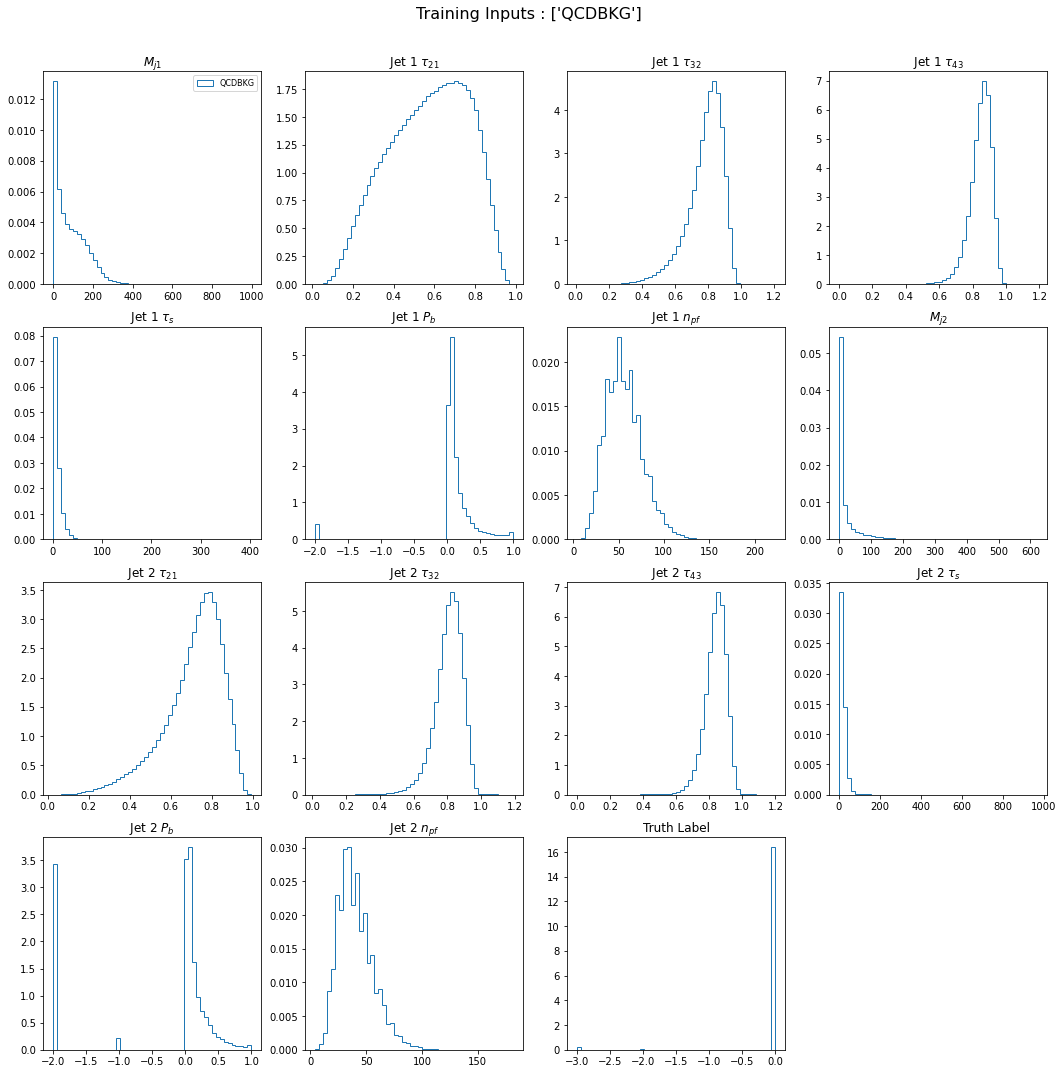

In [4]:
hf.plot_input_variables(train,'QCDBKG',names,save=False)

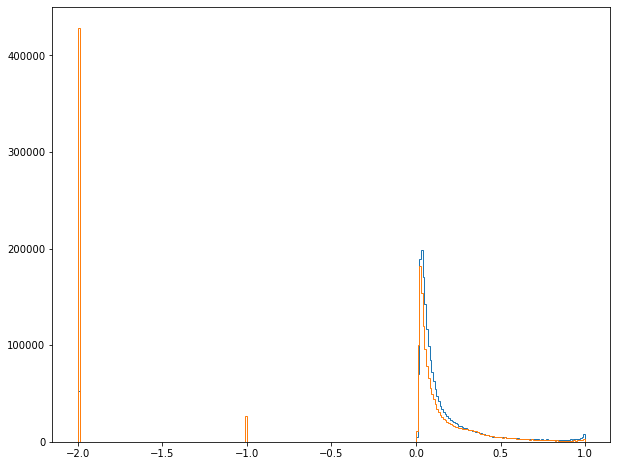

In [27]:
pb1 = train[:,5]
pb2 = train[:,12]
plt.figure(figsize=(10,8))
h1 = plt.hist(pb1,bins=np.arange(-2,1.01,step=0.01),density=False,histtype='step')
h2 = plt.hist(pb2,bins=np.arange(-2,1.01,step=0.01),density=False,histtype='step')

In [61]:
def transform(pb):
    nev = pb.shape[0]
    noise = np.random.normal(loc=0,scale=0.05,size=nev)
    msk = (pb == -2) | (pb == -1)
    add = msk.astype(int) * noise
    shift = np.zeros(nev) + 0.85*(pb==-1).astype(int) + 1.55*(pb==-2).astype(int)
    return pb + add + shift

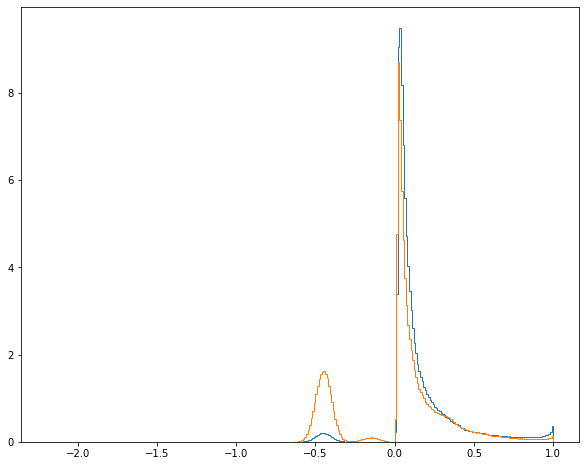

In [62]:
plt.figure(figsize=(10,8))
h1 = plt.hist(transform(pb1),bins=np.arange(-2.2,1.01,step=0.01),density=True,histtype='step')
h2 = plt.hist(transform(pb2),bins=np.arange(-2.2,1.01,step=0.01),density=True,histtype='step')